In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [45]:
df = pd.read_csv(r"C:\Users\sinha\Downloads\customer-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [46]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

(7043, 21)

In [47]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [48]:
df.drop("customerID", axis=1, inplace=True)

In [49]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [50]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

C:\Users\sinha\AppData\Local\Temp\ipykernel_17368\575980950.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [ ]:
import os

print(os.path.exists("../models/churn_model.pkl"))

True


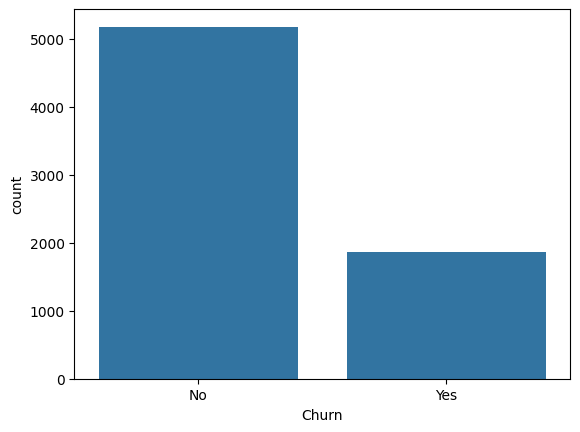

In [51]:
sns.countplot(x="Churn", data=df)
plt.show()

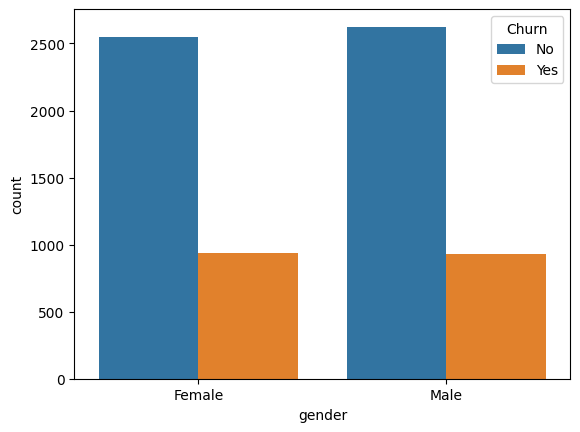

In [52]:
sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.show()

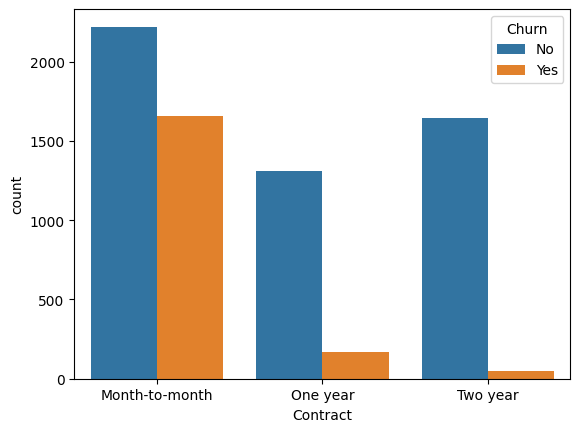

In [53]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

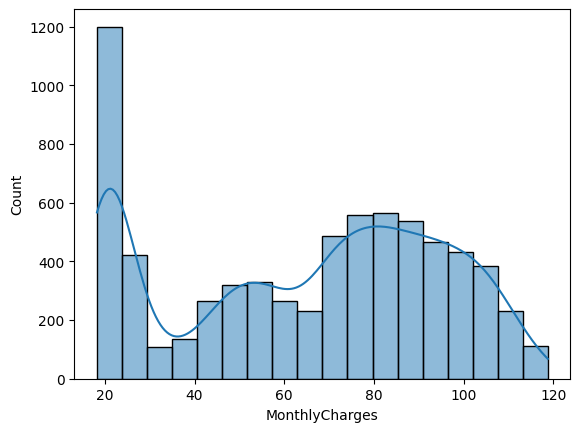

In [54]:
sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.show()

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = le.fit_transform(df[col].astype(str))

In [56]:
df["gender"].head()

0    0
1    1
2    1
3    1
4    0
Name: gender, dtype: int64

In [57]:
df.select_dtypes(exclude=["int64", "float64"]).columns


Index([], dtype='str')

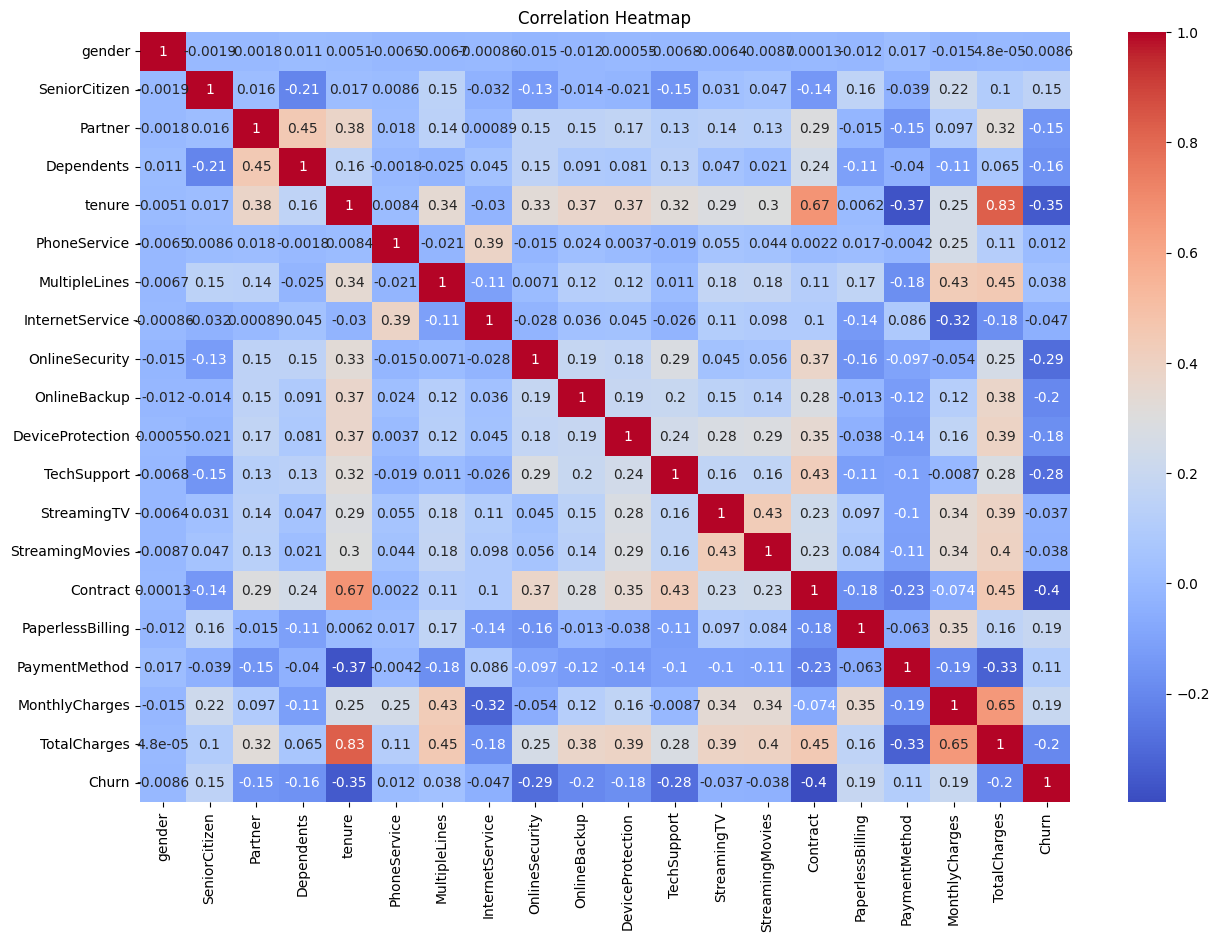

In [58]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [59]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [77]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [78]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [80]:
X.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
dtype: int64

In [81]:
print(X.isnull().sum().sum())

11


In [82]:
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

In [83]:
print(X.isnull().sum().sum())

0


In [84]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

print(results)

c:\Users\sinha\Downloads\customer-churn-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8168914123491838, 'Decision Tree': 0.7295954577714692, 'Random Forest': 0.7955997161107168}


In [86]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [87]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [88]:
comparison_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.816891
1,Decision Tree,0.729595
2,Random Forest,0.795600


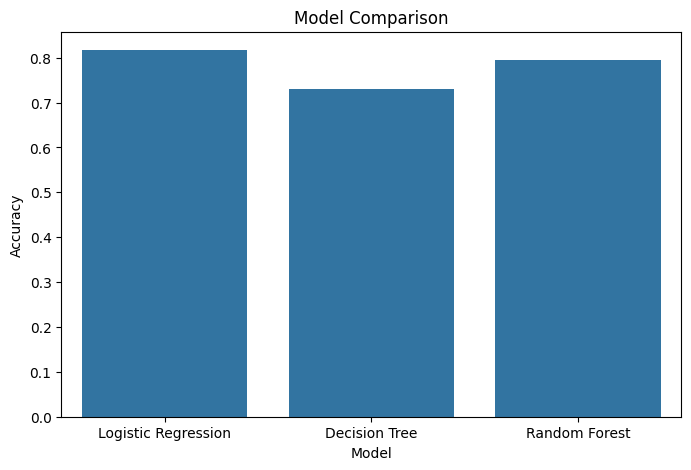

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")
plt.show()

In [90]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.8369592783131656


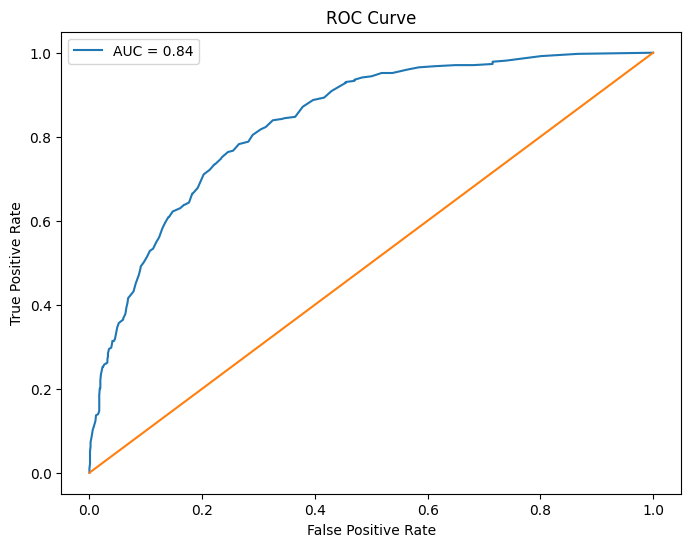

In [91]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

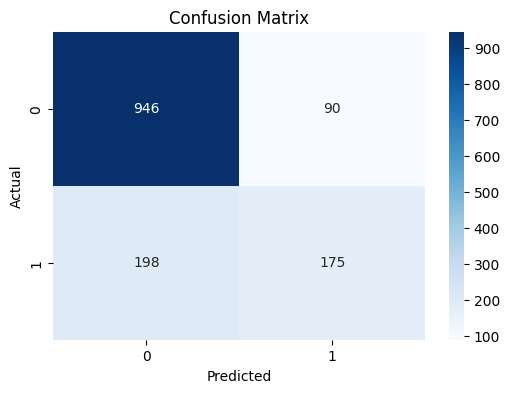

In [92]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [93]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


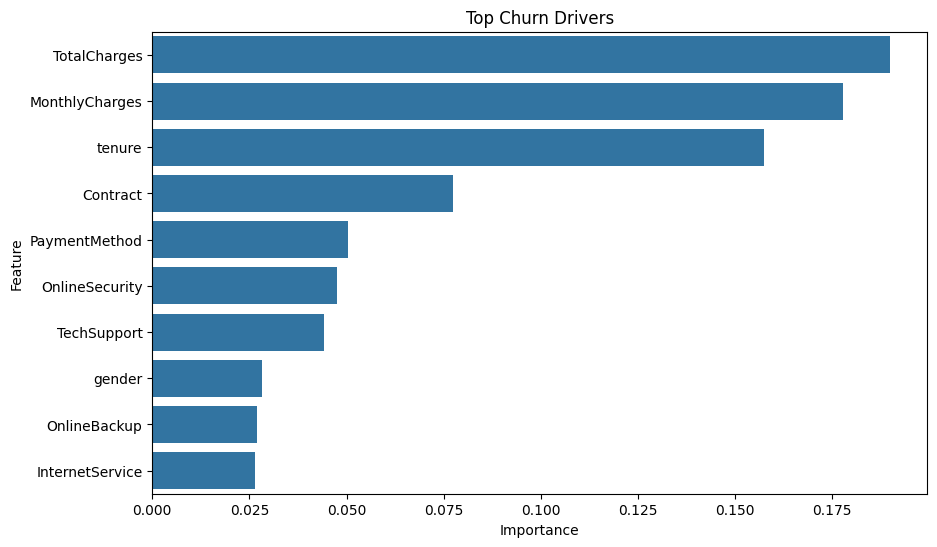

In [94]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Churn Drivers")

plt.show()

In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7955997161107168


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[946  90]
 [198 175]]


In [67]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [70]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [71]:
import os

print(os.path.exists("../models/churn_model.pkl"))

True


In [72]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [73]:
df_original = pd.read_csv(r"C:\Users\sinha\Downloads\customer-churn-prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [75]:
print(df_original["Contract"].unique())

print(df_original["InternetService"].unique())

print(df_original["PaymentMethod"].unique())

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [76]:
import os

os.listdir("../models")

['churn_model.pkl']

In [95]:
df_original = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [96]:
print(df_original["InternetService"].unique())
print(df_original["MultipleLines"].unique())
print(df_original["Contract"].unique())
print(df_original["PaymentMethod"].unique())

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [97]:
from sklearn.preprocessing import LabelEncoder

for col in ["InternetService", "MultipleLines", "Contract", "PaymentMethod"]:
    le = LabelEncoder()
    le.fit(df_original[col])

    print(f"\n{col}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


InternetService
{'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}

MultipleLines
{'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}

Contract
{'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two year': np.int64(2)}

PaymentMethod
{'Bank transfer (automatic)': np.int64(0), 'Credit card (automatic)': np.int64(1), 'Electronic check': np.int64(2), 'Mailed check': np.int64(3)}
